In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [2]:
historic_data = pd.read_csv('data/combined_data/historical/historical_lakevic_data.csv')
historic_data.describe(include='all')
#historic_data.head()


,year,month,region,rainfall,runoff
count,1216.000000,1216,1216,912.000000,1216.000000
unique,NaN,12,4,NaN,NaN
top,NaN,Dec.,Kagera,NaN,NaN
freq,NaN,104,304,NaN,NaN
mean,2012.828947,NaN,NaN,3.092385,308.279029
std,7.318077,NaN,NaN,3.553806,686.719391
min,2000.000000,NaN,NaN,0.010000,0.000000
25%,2006.750000,NaN,NaN,0.415500,2.794500
50%,2013.000000,NaN,NaN,1.835000,41.222000
75%,2019.000000,NaN,NaN,4.597250,294.049750


In [3]:
y = historic_data.runoff
X = historic_data.drop(columns='runoff')

numerical_features = ['year', 'rainfall']
categorical_features = ['month', 'region']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    #('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat_transform', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ],
    remainder='passthrough'
)


In [4]:
#Let's test splitting data at this stage
train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.25, random_state=2)

In [5]:
X_train_processed = preprocessor.fit_transform(train_x)
X_test_processed = preprocessor.transform(test_x)


In [6]:
cat_names = preprocessor.named_transformers_['cat_transform'].get_feature_names_out(categorical_features)
column_names = numerical_features + list(cat_names)
print(len(column_names))
X_train_df = pd.DataFrame(X_train_processed, columns=column_names)
X_test_df = pd.DataFrame(X_test_processed, columns=column_names)
#X_test_df

18


In [7]:
#train_x, test_x, train_y, test_y = train_test_split(X_df, y, test_size=0.25, random_state=2)
flood_model = GradientBoostingRegressor(random_state=2)
flood_model.fit(X_train_processed, train_y)

GradientBoostingRegressor(random_state=2)

In [8]:
random_model = RandomForestRegressor(random_state=2)
random_model.fit(X_train_processed, train_y)

RandomForestRegressor(random_state=2)

In [ ]:
predictions = flood_model.predict(X_test_processed)
print("\nMAE : ", mean_absolute_error(test_y, predictions))
print("\nMSE : ", mean_squared_error(test_y, predictions))
print("\nR2 : ", r2_score(test_y, predictions))
print("\nMAPE : ", mean_absolute_percentage_error(test_y, predictions))


ValueError: continuous is not supported

In [22]:
predictions = random_model.predict(X_test_processed)
print("\nMAE : ", mean_absolute_error(test_y, predictions))
print("\nMSE : ", mean_squared_error(test_y, predictions))
print("\nR2 : ", r2_score(test_y, predictions))


MAE :  188.52206855263157

MSE :  142007.6151199836

R2 :  0.6070658510621008


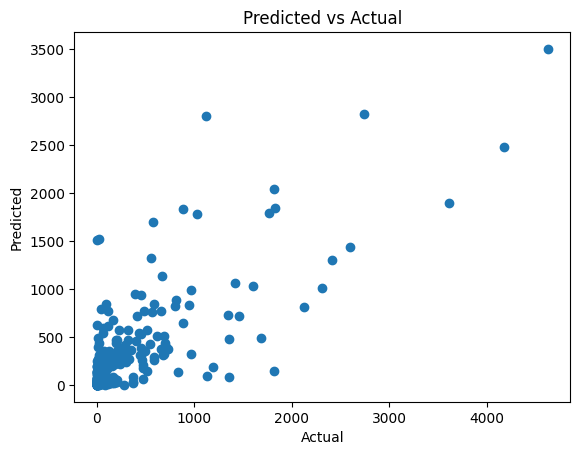

In [23]:
import matplotlib.pyplot as plt
plt.scatter(test_y, predictions)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()
